# Mini-Project : Data Analysis for Marketing Strategy

## Task
### First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

##### Which states have the most sales?
##### What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
##### Who is an outstanding customer in New York?
##### Are there any differences among states in profitability?
##### The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
##### What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
##### What are the Top 20 customers by Sales?
##### Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
##### Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [14]:
#Loading and preprocessing the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
store_dataset = pd.read_excel("data/US Superstore data.xls")


In [16]:
store_dataset.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
store_dataset.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [18]:
# Checking for duplicates
duplicates = store_dataset.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Number of duplicate rows: 0


In [19]:
# There are no duplicate rows in the dataset. We can proceed with our analysis without needing to remove any duplicates.

In [62]:
store_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [21]:
# We can see that there are no missing values. We are moving forward with the analysis.

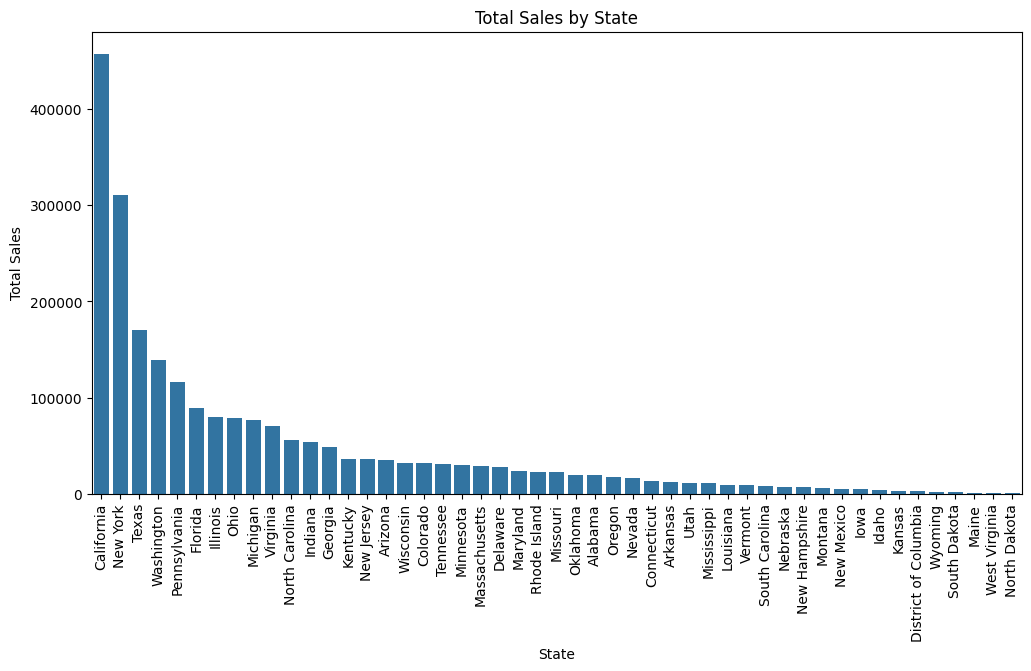

In [22]:
# Which states have the most sales?

sales_by_state = store_dataset.groupby("State")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_state.index, y=sales_by_state.values)
plt.xticks(rotation=90)
plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.show()


In [ ]:
# California has the highest sales. 

In [ ]:
# What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
sales_profit_by_state = store_dataset.groupby("State")[["Sales", "Profit"]].sum()
ny_sales_profit = sales_profit_by_state.loc["New York"]
ca_sales_profit = sales_profit_by_state.loc["California"]
print(f"New York Sales: {ny_sales_profit['Sales']}, Profit: {ny_sales_profit['Profit']}")
print(f"California Sales: {ca_sales_profit['Sales']}, Profit: {ca_sales_profit['Profit']}")

sales_difference = ny_sales_profit["Sales"] - ca_sales_profit["Sales"]
profit_difference = ny_sales_profit["Profit"] - ca_sales_profit["Profit"]
print(f"Sales difference between New York and California: {sales_difference}")
print(f"Profit difference between New York and California: {profit_difference}")

New York - Sales: 310876.271, Profit: 74038.5486
California - Sales: 457687.6315, Profit: 76381.38709999999
Sales difference between New York and California: -146811.3605
Profit difference between New York and California: -2342.838499999998


In [40]:
#First way to find the most outstanding customer
most_outstanding_customers = store_dataset[store_dataset["State"] == "New York"].groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
most_outstanding_customer = most_outstanding_customers.index[0]
print(f"The most outstanding customer is: {most_outstanding_customer}")



The most outstanding customer is: Tom Ashbrook


In [39]:
# Second way to find the most outstanding customer
most_outstanding_customer = store_dataset[store_dataset["State"] == "New York"].groupby("Customer Name")["Sales"].sum().idxmax()
print(f"The most outstanding customer is: {most_outstanding_customer}")

The most outstanding customer is: Tom Ashbrook


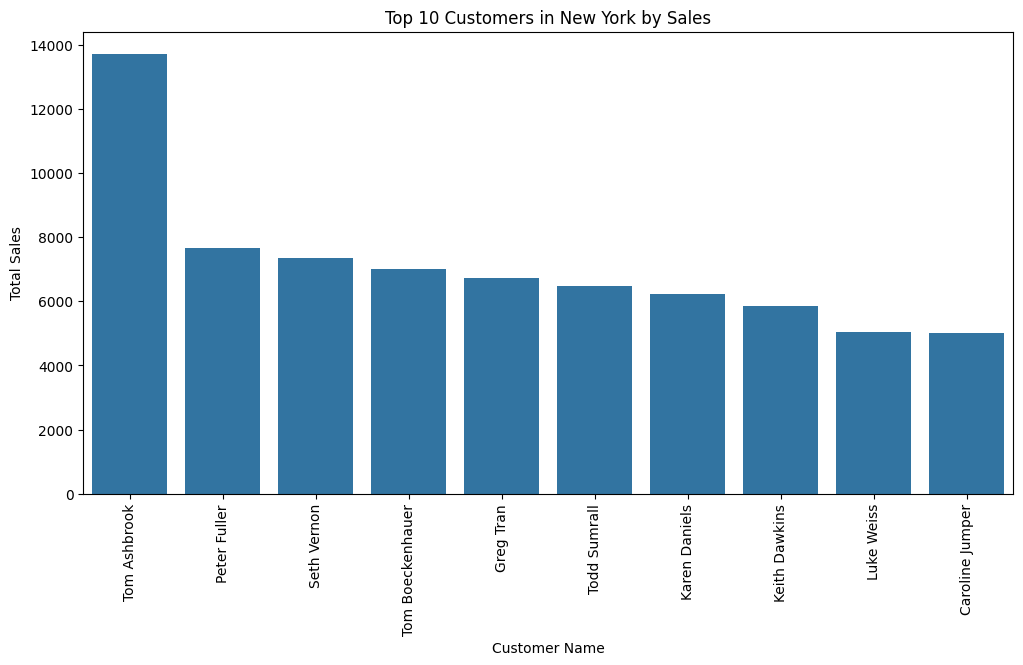

In [36]:
# Visualizing the top 10 customers in New York
ny_customers = store_dataset[store_dataset["State"] == "New York"].groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=ny_customers.index, y=ny_customers.values)
plt.xticks(rotation=90)
plt.title("Top 10 Customers in New York by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.show()

In [46]:
profit_differences_among_states_data = profit_differences_among_states = store_dataset.groupby("State")["Profit"].sum().idxmax()
print(f"The state with the highest profit is: {profit_differences_among_states_data}")

The state with the highest profit is: California


Text(0, 0.5, 'Total Profit')

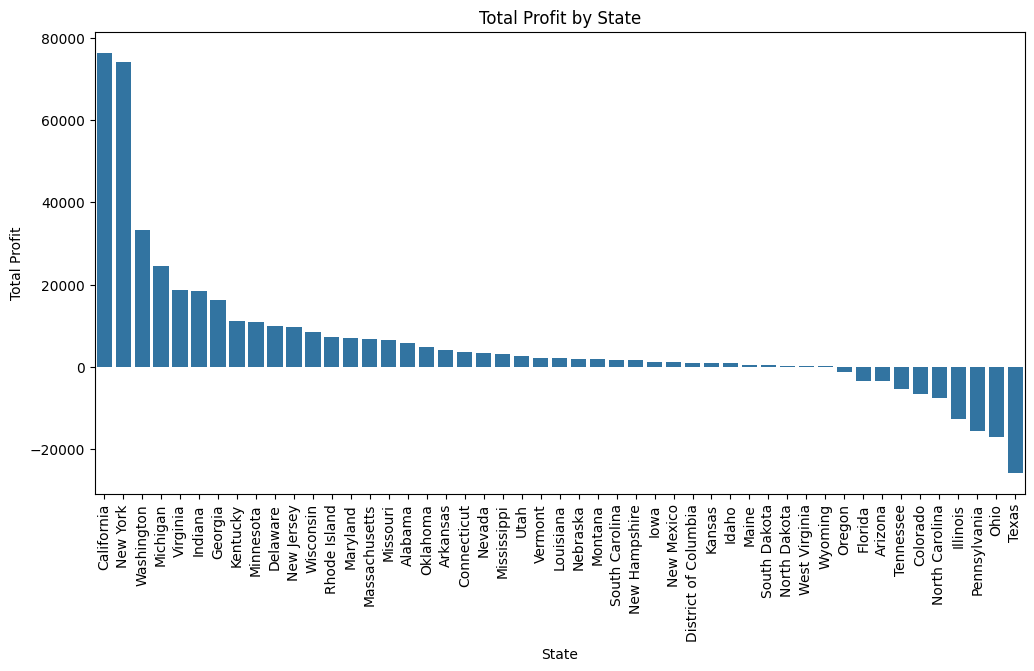

In [ ]:
profit_differences_among_states = store_dataset.groupby("State")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=profit_differences_among_states.index, y=profit_differences_among_states.values)
plt.xticks(rotation=90)
plt.title("Total Profit by State")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.show()

In [ ]:
# We can see that there are indeed significant differences in profit among states. 

Total Profit: 286397.0216999999
Profit from top 20% customers: 233201.2807999999
Percentage of total profit from top 20% customers: 81.43%


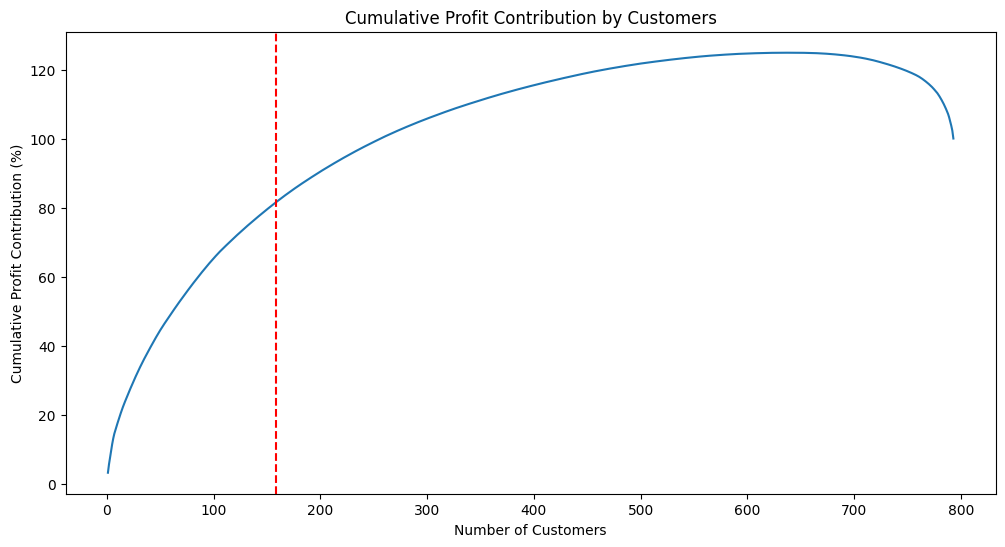

In [54]:
# The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)

# Calculate total profit
total_profit = store_dataset["Profit"].sum()

# Calculate profit contribution by each customer
customer_profit_contribution = store_dataset.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)
cumulative_profit = customer_profit_contribution.cumsum()
customer_count = len(customer_profit_contribution)
top_20_percent_customers = int(0.2 * customer_count)
profit_from_top_20_percent_customers = cumulative_profit.iloc[top_20_percent_customers - 1]
profit_percentage = (profit_from_top_20_percent_customers / total_profit) * 100
print(f"Total Profit: {total_profit}")
print(f"Profit from top 20% customers: {profit_from_top_20_percent_customers}")
print(f"Percentage of total profit from top 20% customers: {profit_percentage:.2f}%")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, customer_count + 1), y=cumulative_profit / total_profit * 100)
plt.axvline(x=top_20_percent_customers, color='red', linestyle='--')
plt.title("Cumulative Profit Contribution by Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Profit Contribution (%)")
plt.show()

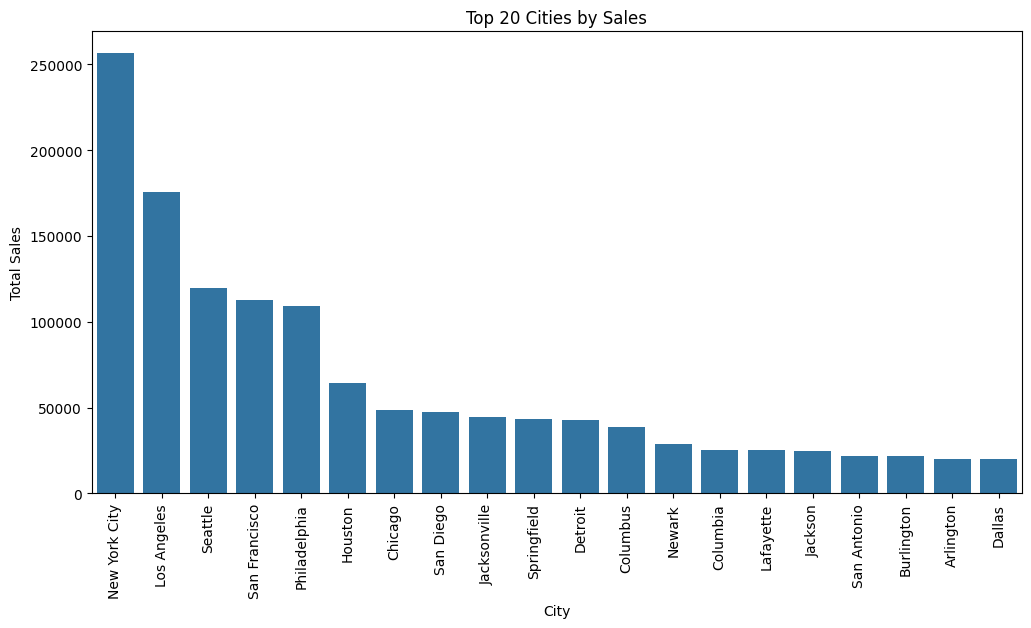

In [57]:
top_20_cities_by_sales = store_dataset.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_cities_by_sales.index, y=top_20_cities_by_sales.values)
plt.xticks(rotation=90)
plt.title("Top 20 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()


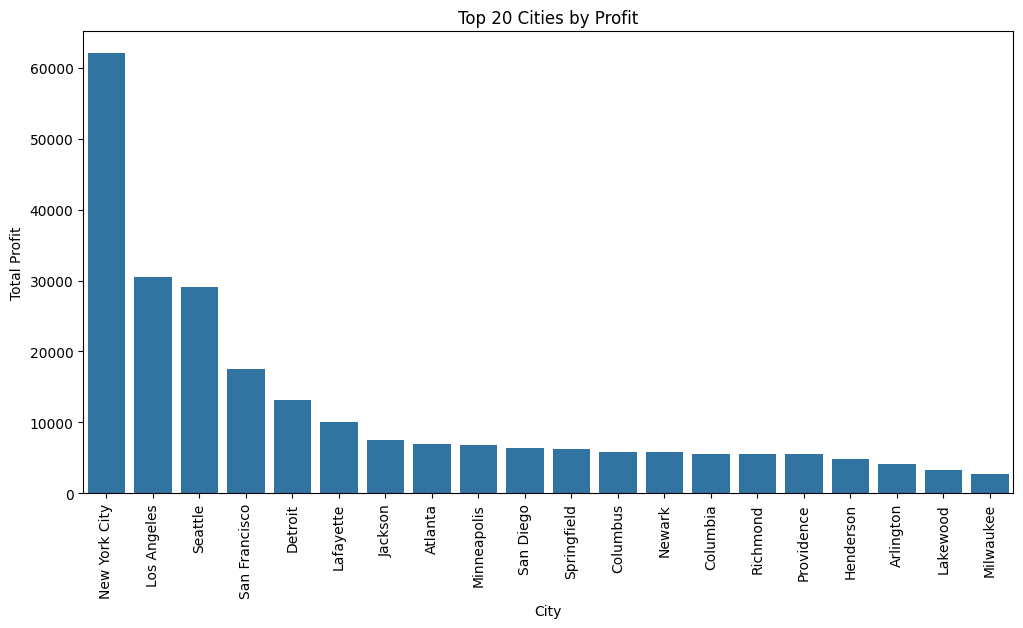

In [58]:
top_20_cities_by_profit = store_dataset.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_cities_by_profit.index, y=top_20_cities_by_profit.values)
plt.xticks(rotation=90)
plt.title("Top 20 Cities by Profit")
plt.xlabel("City")
plt.ylabel("Total Profit")
plt.show()

Customer Name
Adrian Barton           14473.571
Adam Bellavance          7755.620
Alan Dominguez           6106.880
Alan Hwang               4805.344
Alan Schoenberger        4260.784
Adam Shillingsburg       3255.310
Adam Hart                3250.337
Alejandro Savely         3214.236
Aaron Smayling           3050.692
Alejandro Grove          2582.898
Aaron Hawkins            1744.700
Adrian Hane              1735.514
Alan Haines              1587.452
Alan Barnes              1113.838
Aimee Bixby               966.710
Alejandro Ballentine      914.532
Aaron Bergman             886.156
Alan Shonely              584.608
Aleksandra Gannaway       367.548
Adrian Shami               58.820
Name: Sales, dtype: float64


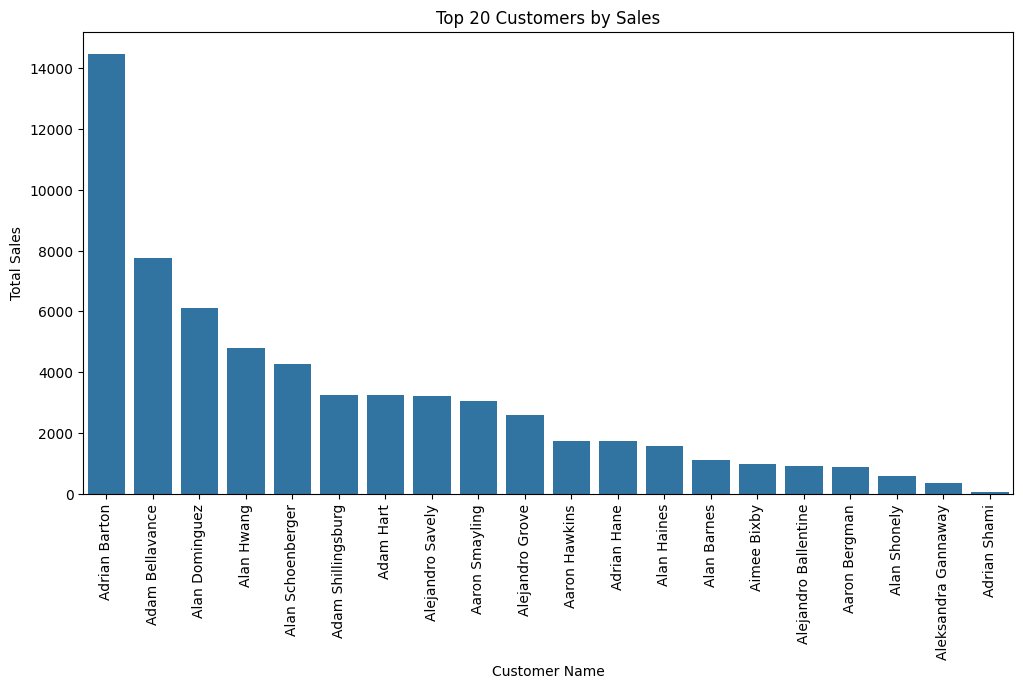

In [52]:
top_20_customers_by_sales = store_dataset.groupby("Customer Name")["Sales"].sum().head(20).sort_values(ascending=False)
# print(top_20_customers_by_sales)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_customers_by_sales.index, y=top_20_customers_by_sales.values)
plt.xticks(rotation=90)
plt.title("Top 20 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.show()


Total Sales: 2297200.8603
Sales from top 20% customers: 1101781.3861
Percentage of total sales from top 20% customers: 47.96%


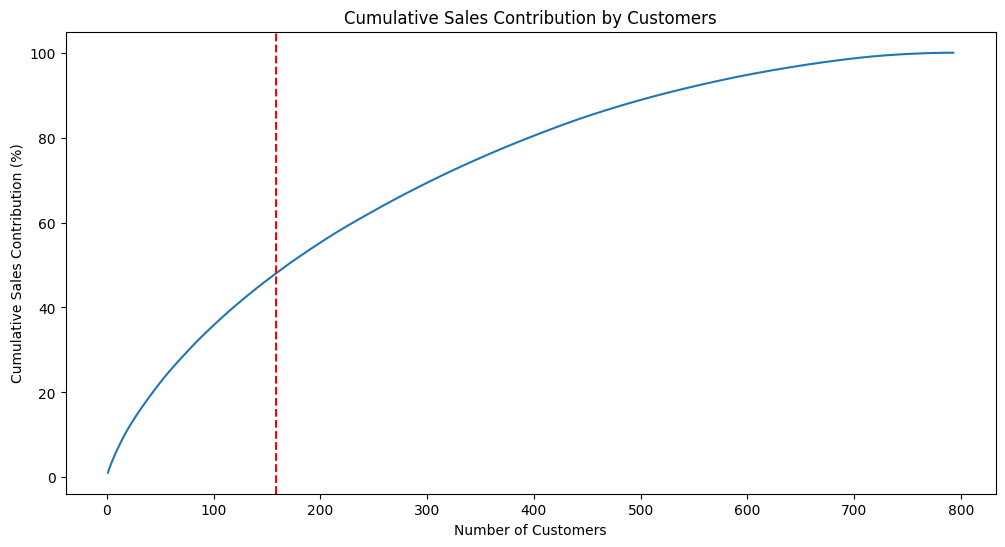

In [60]:
# Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

# Calculate total sales
total_sales = store_dataset["Sales"].sum()
# Calculate sales contribution by each customer
customer_sales_contribution = store_dataset.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
cumulative_sales = customer_sales_contribution.cumsum()
customer_count = len(customer_sales_contribution)
top_20_percent_customers = int(0.2 * customer_count)
sales_from_top_20_percent_customers = cumulative_sales.iloc[top_20_percent_customers - 1]
sales_percentage = (sales_from_top_20_percent_customers / total_sales) * 100
print(f"Total Sales: {total_sales}")
print(f"Sales from top 20% customers: {sales_from_top_20_percent_customers}")
print(f"Percentage of total sales from top 20% customers: {sales_percentage:.2f}%")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, customer_count + 1), y=cumulative_sales / total_sales * 100)
plt.axvline(x=top_20_percent_customers, color='red', linestyle='--')
plt.title("Cumulative Sales Contribution by Customers")
plt.xlabel("Number of Customers")
plt.ylabel("Cumulative Sales Contribution (%)")
plt.show()

In [ ]:
# Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

# Prioritize states with high sales and profit
# We should focus our marketing efforts on California and New York, as they have the highest sales and profit. 
# Additionally, we can target other states with significant sales and profit contributions.